# Final project - Flood in Bangladesh

In [1]:
from pyhdf.SD import SD, SDC
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

/home/sol/venv/lib/python3.10/site-packages/geopandas/_compat.py:111: UserWarning: The Shapely GEOS version (3.11.3-CAPI-1.17.3) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
f27= '/home/sol/Downloads/MCDWD_L3_NRT.A2024250.h27v06.061.hdf'
f26= '/home/sol/Downloads/MCDWD_L3_NRT.A2024250.h26v06.061.hdf'
variable = 'Flood_2Day_250m'
output_directory = '/home/sol/Downloads/'

In [3]:
hdf = SD(f26, SDC.READ)
data26 = hdf.select(variable)[:]

hdf = SD(f27, SDC.READ)
data27 = hdf.select(variable)[:]

In [4]:
new_data = np.concatenate((data26, data27), axis = 1)

## Plot the data

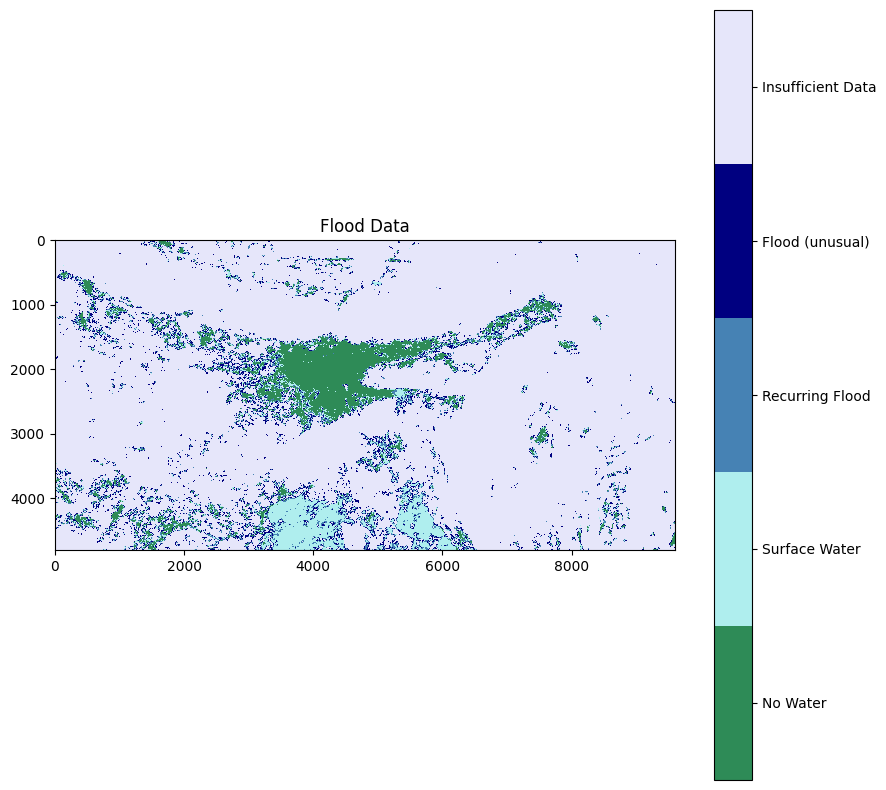

In [5]:
colors = ['seagreen', 'paleturquoise', 'steelblue', 'navy','lavender']
plot_data = new_data.copy()
plot_data[plot_data == 255] = 4 # map 255 to 4 so it looks neat
# Create custom colormap
cmap = ListedColormap(colors)
# Create the plot
plt.figure(figsize=(10, 10))
im = plt.imshow(plot_data, cmap=cmap, vmin=0, vmax=4)

# Create custom colorbar
cbar = plt.colorbar(im, ticks=[0.4, 1.2, 2, 2.8, 3.6])
cbar.ax.set_yticklabels(['No Water', 'Surface Water', 'Recurring Flood', 'Flood (unusual)', 'Insufficient Data'])  # Replace 4 with 255

plt.title('Flood Data')

plt.show()

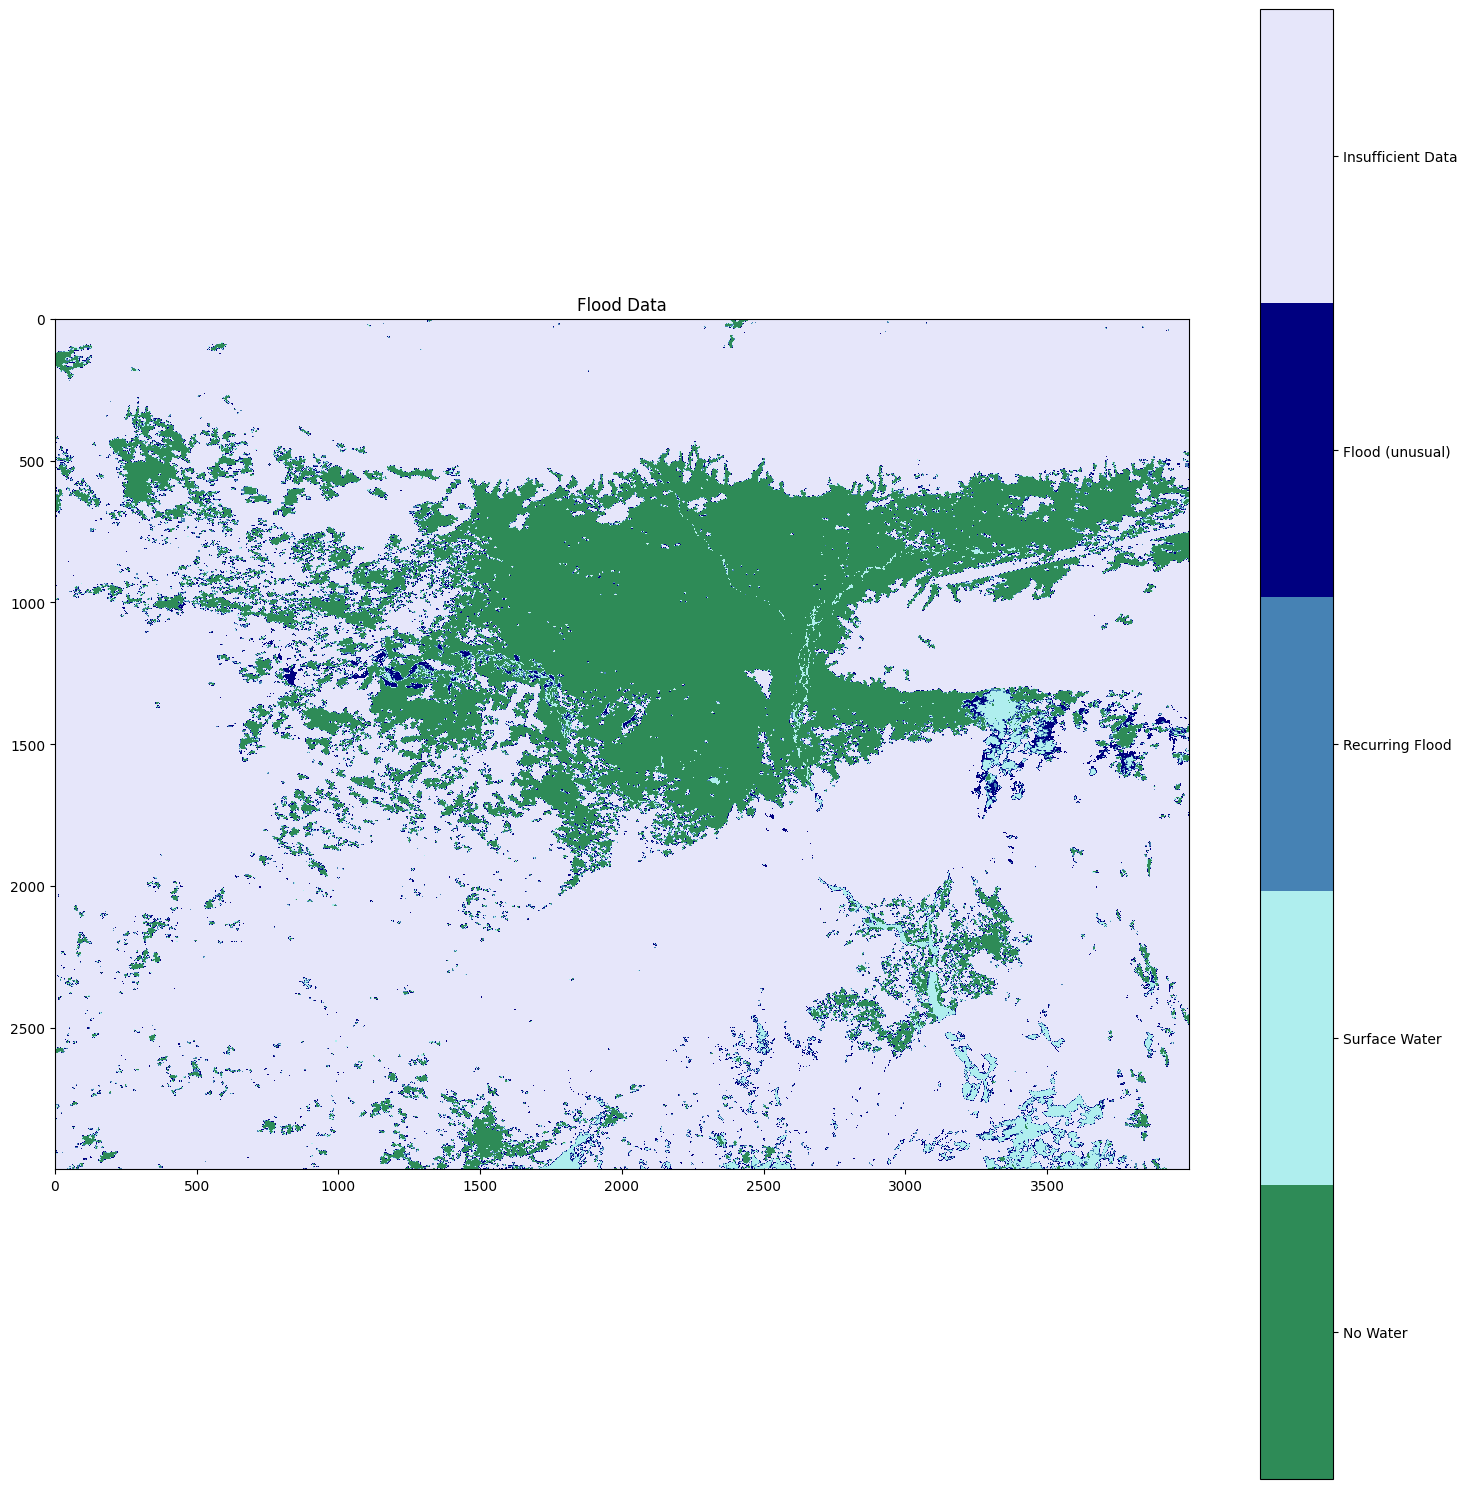

In [6]:
colors = ['seagreen', 'paleturquoise', 'steelblue', 'navy','lavender']
plot_data = new_data.copy()
plot_data[plot_data == 255] = 4 # map 255 to 4 so it looks neat
# Create custom colormap
cmap = ListedColormap(colors)
# Create the plot
plt.figure(figsize=(15, 15))
im = plt.imshow(plot_data[1000:4000, 2000:6000], cmap=cmap, vmin=0, vmax=4)

# Create custom colorbar
cbar = plt.colorbar(im, ticks=[0.4, 1.2, 2, 2.8, 3.6])
cbar.ax.set_yticklabels(['No Water', 'Surface Water', 'Recurring Flood', 'Flood (unusual)', 'Insufficient Data'])  # Replace 4 with 255

plt.title('Flood Data')

plt.tight_layout()
plt.show()

In [7]:
import folium
import numpy as np
from folium.raster_layers import ImageOverlay

In [8]:
small = new_data[1000:4000, 2000:6000]

In [9]:
h26v06 = rasterio.open('/home/sol/Downloads/MCDWD_L3_F1C_NRT.A2025031.h26v06.061.tif')
h27v06 = rasterio.open('/home/sol/Downloads/MCDWD_L3_F1C_NRT.A2025031.h27v06.061.tif')

In [10]:
southwest = [h26v06.xy(4000, 2000)[1], h26v06.xy(4000, 2000)[0]]
northeast = [h27v06.xy(1000, 6000-4800)[1], h27v06.xy(1000, 6000-4800)[0]]
center = [h26v06.xy(2500, 4000)[1], h26v06.xy(2500, 4000)[0]]

In [11]:
bounds = [southwest, northeast]


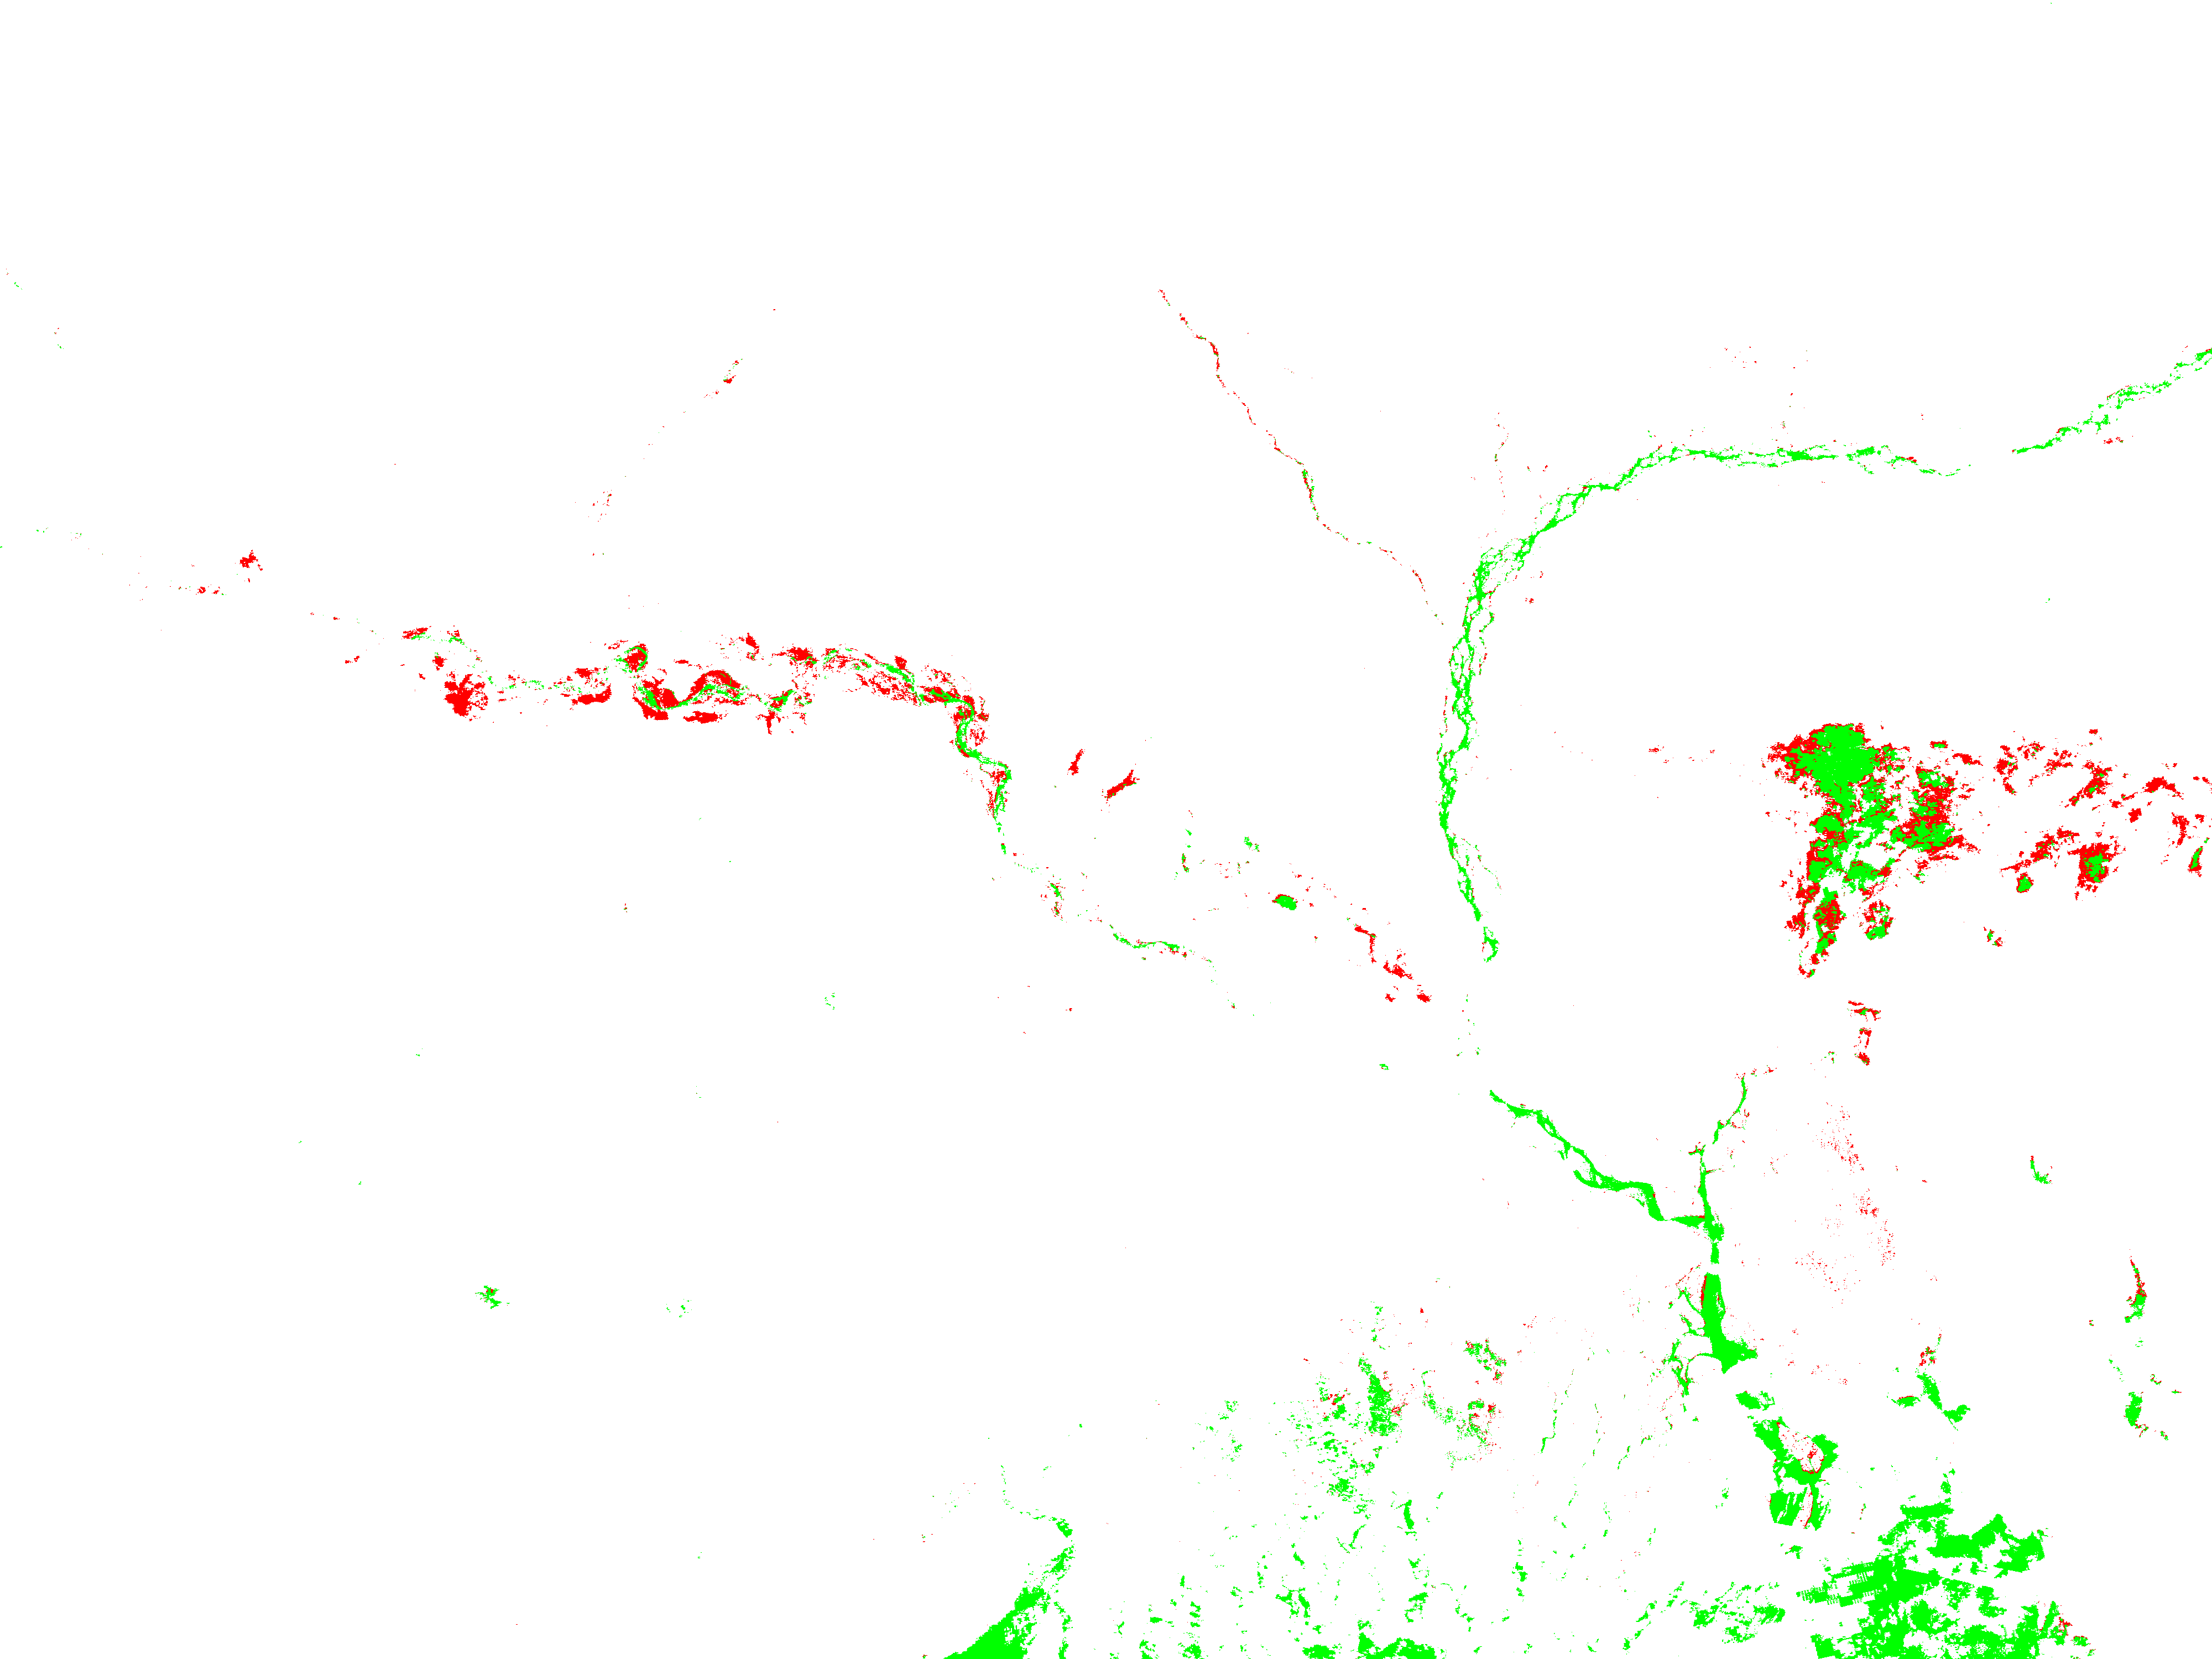

In [12]:
def colormap(value):
    color_dict = {
        1: (0, 255, 0, 255),      # Green for 1, Surface water
        2: (255, 255, 0, 255),    # Yellow for 2, Recurring flood
        3: (255, 0, 0, 255),    # Red for 3, Flood (unusual)
    }
    return color_dict.get(value, (0, 0, 0, 0))  # Default to transparent for other values

# Convert raster to an RGBA image using the colormap
rgba_raster = np.zeros((small.shape[0], small.shape[1], 4), dtype=np.uint8)
for value, color in [(1, colormap(1)), (2, colormap(2)), (3, colormap(3))]:
    mask = small == value
    rgba_raster[mask] = color
    
google_maps = folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=m&hl=es&x={x}&y={y}&z={z}", 
    attr="Google Maps", 
    name="Google Maps (Spanish)"
)

# Create a Folium map
m = folium.Map(location=center, zoom_start=10)

# Add the ndarray as an overlay
image = ImageOverlay(
    image=rgba_raster,
    bounds=bounds,
    opacity=0.7,
    interactive=True
)
google_maps.add_to(m)
image.add_to(m)
m

## Save data as GeoTiff

### Check the edges of the first image (left)

In [13]:
h26v06.xy(0,0)

(80.00104166666667, 29.998958333333334)

In [14]:
h26v06.xy(4800,4800)

(90.00104166666667, 19.998958333333334)

### Create the affine transformation matrix
This matrix will give the lat-lon to each pixel

In [39]:
from rasterio.transform import from_origin

# Example: Define the spatial extent
xmin, ymin, xmax, ymax = 80, 20, 100, 30 
xres = (xmax - xmin) / 9600
yres = (ymax - ymin) / 4800

# Create affine transformation
transform = from_origin(xmin, ymax, xres, yres)

In [40]:
transform

Affine(0.0020833333333333333, 0.0, 80.0,
       0.0, -0.0020833333333333333, 30.0)

### Save the data

In [41]:
# Define saving parameters
new_dataset = rasterio.open(
    '/home/sol/Downloads/new.tif',
    'w',
    driver='GTiff',
    height=4800,
    width=9600,
    count=1,
    dtype=new_data.dtype,
    crs='+proj=latlong',
    transform=transform,
)
#Save
new_dataset.write(new_data, 1)